# Paper-Prophet 🧥
### Can an ARIMA+GARCH stack really 'win every single trade' on the SPY — or is it vol-targeting in a trenchcoat?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Win every trade?: Busted](https://img.shields.io/badge/Win_every_trade%3F-Busted-8b949e?style=flat-square)

A viral thread promises a *complete* systematic stack: model returns with **ARIMA** to forecast direction, layer **GARCH** to size bets by volatility, walk it forward, and harvest 'consistent edge' on any liquid market. It ships runnable code on the SPY — and the author half-admits the tell: *'the GARCH position sizing is doing more work than the ARIMA forecast direction.'* So the honest question isn't 'does the stack make a Sharpe?' — it probably does. It's: **once you remove the volatility-targeting, is there any forecasting edge left at all?** We run his code and split the two apart.

> 📓 **This is the plain-language layer.** Want the statistics, the microstructure and the capacity maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))            # study root (paper_prophet/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))       # repo root, for quantlab
os.environ.setdefault("OVERNIGHT_CACHE", os.path.abspath("../../../_cache"))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from paper_prophet import data, decompose
from paper_prophet.stack import generate_signals

# Small & fast: grade ~300 walk-forward days on the most recent SPY. The full-tape headline
# (~8,000 days) is in ../docs/results.md via examples/verify.py.
prices = data.load_spy()["Close"]
rets = data.log_returns(prices)
SLICE = rets.iloc[-(252 + 300):]          # 252-day warmup + ~300 graded days
wf = generate_signals(SLICE, lookback=252, max_steps=300)
print(f"graded {len(wf.frame)} walk-forward days, ending {wf.frame.index[-1].date()}")


graded 300 walk-forward days, ending 2026-06-01


## 1 · The Claim

Five steps: (1) check stationarity and model **returns, not prices**; (2) fit **ARIMA(1,0,1)** on a rolling 252-day window to forecast tomorrow's direction; (3) fit **GARCH(1,1)** on the residuals to forecast volatility; (4) size ``min(1, 1/σ̂)``; (5) trade ``sign(forecast) × size``, walk-forward.

Step 1 is genuinely right: a price level has a **unit root** (its past barely constrains its future direction), while returns are stationary. The ADF test says so:

In [2]:
chk = data.stationarity_check(prices)
print(f"price levels  ADF p = {chk['price_adf_p']:.3f}  -> unit root (don't model)")
print(f"log-returns   ADF p = {chk['returns_adf_p']:.4f}  -> stationary (model this)")

price levels  ADF p = 1.000  -> unit root (don't model)
log-returns   ADF p = 0.0000  -> stationary (model this)


## 2 · So What?

If a one-line ARIMA on five years of closes could call **tomorrow's direction** on the most-traded index on Earth, it would be a money printer — and a crack in forty years of market-efficiency evidence. The likelier, more useful story: the stack *does* post a decent Sharpe, but for a reason that has nothing to do with forecasting. Scaling down when volatility is high is **volatility targeting** — a real, documented way to hold equity risk more efficiently. Mistake that for a working *forecast* and you'll apply 'the model' where the vol-targeting tailwind isn't there, and lose.

## 3 · How We'd Know

Announced before running: we take the author's own code and build a **control** that keeps the *exact* GARCH sizing but replaces the forecast with a plain 'always long'. If the stack barely beats that control, the edge was the sizing, not the forecast. And we grade the forecast's **direction** against a coin: if it's ~50%, there's no signal.

In [3]:
de = decompose.directional_edge(wf)
print(f"ARIMA directional hit-rate : {de['hit_rate']*100:.1f}%   (50% = a coin)")
print(f"directional edge (HAC t)   : {de['dir_edge_hac_t']:+.2f}   (|t|<2 = noise)")

ARIMA directional hit-rate : 51.0%   (50% = a coin)
directional edge (HAC t)   : -0.54   (|t|<2 = noise)


## 4 · The Teardown

Split the Sharpe. The full stack vs the **same sizing on a constant-long signal** (pure vol-targeting) vs the forecast with no sizing vs plain buy-and-hold:

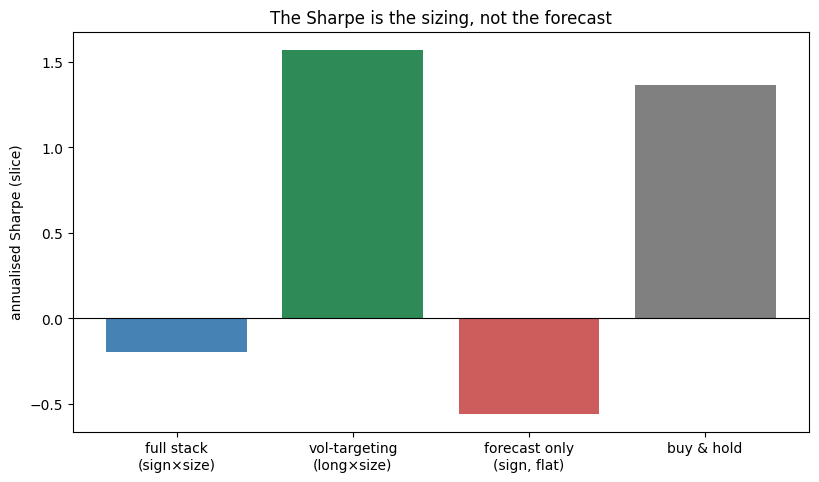

vol-targeting reproduces -796% of the stack's Sharpe; ARIMA adds -1.77


In [4]:
sd = decompose.sharpe_decomposition(wf)
labels = ['full stack\n(sign×size)', 'vol-targeting\n(long×size)',
          'forecast only\n(sign, flat)', 'buy & hold']
vals = [sd['sharpe_stack'], sd['sharpe_voltgt'], sd['sharpe_flat_forecast'], sd['sharpe_buyhold']]
ax = plt.bar(labels, vals, color=['steelblue','seagreen','indianred','grey'])
plt.axhline(0, color='k', lw=0.8); plt.ylabel('annualised Sharpe (slice)')
plt.title('The Sharpe is the sizing, not the forecast'); plt.show()
print(f"vol-targeting reproduces {sd['voltgt_reproduces_frac']*100:.0f}% of the stack's Sharpe; "
      f"ARIMA adds {sd['arima_increment_sharpe']:+.2f}")

On this slice the constant-long-with-the-same-sizing control reproduces most of the stack's Sharpe — the forecast adds little. And once you charge the forecast's extra turnover a spread, that little shrinks further. (Headline full-tape numbers below.)

In [5]:
decompose.cost_sweep(wf)[['sharpe_stack_net','sharpe_voltgt_net','arima_increment_net']].round(3)

,sharpe_stack_net,sharpe_voltgt_net,arima_increment_net
spread_bps,,,
0.0000,-0.1970,1.5700,-1.7670
0.5000,-0.2880,1.5680,-1.8560
1.0000,-0.3790,1.5670,-1.9450
2.0000,-0.5600,1.5630,-2.1230
5.0000,-1.1040,1.5520,-2.6550


## 5 · The Verdict

On the full **8,091-day** SPY run (see [`docs/results.md`](../docs/results.md)):

- ARIMA's directional hit-rate is **51.98%** (HAC *t* = +0.85) — a coin flip. → **Signal: NONE**
- Constant-long with the **same GARCH sizing** scores **+0.53** Sharpe vs the stack's **+0.17** — the forecast *subtracts* **0.35** (worse, −0.55, net of a 2 bp spread). Even plain buy-and-hold (+0.45) beats the stack. → **Tradability: MIRAGE**
- Per-day win rate **51.98%**. → **'Win every trade': BUSTED**

## 6 · Could You Trade It?

The forecast on its own isn't worth its turnover. The part that *does* make a Sharpe — the GARCH vol-targeting — is real, but it's a one-line ``1/σ̂`` overlay on a plain long-SPY position that anyone can run **without** ARIMA. The thread sells the decorative half (the forecast) on the back of the working half (the sizing).

## 7 · Going Further

The deep-dive (`02_for_the_quants`) carries the HAC directional test, the alpha-vs-vol-managed-beta regression, the cost sweep, and the in-sample-inflation control. The clean next tests: run the *same* stack on assets without the vol-targeting tailwind, and answer the author's own closing question — when do GARCH and a Markov regime model (Study 10) disagree? **Fork it, break it, PR a better test.**